# <span style="color: #57A0D2"> Essay</span> <span style="color: #4D516D">Analysis </span>

In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

### <span style="color: #4D516D">1. Loading the Dataset</span>

In [5]:
with open('Essay3.txt', 'r', encoding='utf-8-sig') as f:
    text = f.read()

text = re.sub(r'\n+', ' ', text)
text = re.sub(r'\s{2,}', ' ', text).strip()

# Fixed regex - no spaces around |
pattern = re.compile(r'(?<=[.!?])\s+(?=[A-Z\[\("])|(?<=[.!?])$')
raw_sentences = pattern.split(text)

sentences = []
for s in raw_sentences:
    s = s.strip()
    if len(s) < 10:
        continue
    if not re.search(r'[.!?"\)]$', s) and len(s.split()) < 8:
        continue
    sentences.append(s)

df = pd.DataFrame(sentences, columns=['sentence'])
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} column')

# Safe preview - no hardcoded indices
indices = [i for i in [2, 5, 10, 20, 50, 100, 150, 200] if i < len(df)]
for i, row in df.iloc[indices].iterrows():
    print(f'  Row {i}: {row["sentence"][:120]}...')
    print()

Shape: 785 rows x 1 column
  Row 2: Choice, in this familiar image, implies authorship....

  Row 5: If the self is impermanent, composite, and dependent upon countless prior causes, and if “we can see ourselves in this s...

  Row 10: Even now, as I continue writing, the movement forward feels intentional, yet it is inseparable from earlier readings, cl...

  Row 20: But the boundaries of what feels imaginable were not drawn in the moment of choice, but gradually through my upbringing....

  Row 50: In approaching this essay, I want to begin by acknowledging that resistance rather than smoothing it over....

  Row 100: Mastery appears to depend on the condition of movement, and explanation begins to look less like a pathway towards true ...

  Row 150: But rather than treating this gap as establishing that the fetus has no moral standing whatsoever, Warren’s framework is...

  Row 200: In the most literal sense, Nora becomes plural: she exists as who she believes herself to be, and as

### <span style="color: #4D516D">2. Cleaning Text (lowercase)</span>
Text analysis tools treat "Choice" and "choice" as two completely different tokens by default. Lowercasing ensures they are counted as the same word, which:
- Prevents artificial inflation of the vocabulary (no duplicate entries for capitalized vs. uncapitalized versions)
- Makes word frequency counts more accurate
- Ensures vectorizers like CountVectorizer and TF-IDF treat the same word consistently regardless of where it appears in a sentence

In [20]:
# Convert every sentence to lowercase and store in a new column
df['clean_text'] = df['sentence'].str.lower()

print('--- Original vs Lowercase ---')
for i in [2, 5, 10]:
    print(f'ORIGINAL : {df["sentence"].iloc[i][:100]}')
    print(f'LOWERCASE: {df["clean_text"].iloc[i][:100]}')
    print()

print('DataFrame now has columns:', list(df.columns))

--- Original vs Lowercase ---
ORIGINAL : Choice, in this familiar image, implies authorship.
LOWERCASE: choice, in this familiar image, implies authorship.

ORIGINAL : If the self is impermanent, composite, and dependent upon countless prior causes, and if “we can see
LOWERCASE: if the self is impermanent, composite, and dependent upon countless prior causes, and if “we can see

ORIGINAL : Even now, as I continue writing, the movement forward feels intentional, yet it is inseparable from 
LOWERCASE: even now, as i continue writing, the movement forward feels intentional, yet it is inseparable from 

DataFrame now has columns: ['sentence', 'clean_text']


### <span style="color: #4D516D">3. Removing Punctuation</span>
Punctuation and numbers carry no thematic meaning for bag-of-words analysis. Leaving them in would cause `"choice,"` and `"choice"` to be treated as different tokens, polluting the vocabulary with noise. Extra spaces can also create empty tokens during tokenization. Cleaning first ensures every token is a real, meaningful word.

In [21]:
def clean_sentence(text):
    text = re.sub(r'[^a-z\s]', '', text)   # remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip() # collapse extra spaces
    return text

df['clean_text'] = df['clean_text'].apply(clean_sentence)

# Pick a content-rich sentence to compare
idx = 10
print('=== ORIGINAL SENTENCE ===')
print(df['sentence'].iloc[idx])
print()
print('=== CLEANED SENTENCE ===')
print(df['clean_text'].iloc[idx])
print()

# Show what was removed
original_chars = set(df['sentence'].iloc[idx])
clean_chars    = set(df['clean_text'].iloc[idx])
removed        = original_chars - clean_chars
print(f'Characters removed: {sorted(removed)}')

=== ORIGINAL SENTENCE ===
Even now, as I continue writing, the movement forward feels intentional, yet it is inseparable from earlier readings, classroom exchanges, and perhaps even the quiet pressure of wanting to resolve an unsettling question.

=== CLEANED SENTENCE ===
even now as i continue writing the movement forward feels intentional yet it is inseparable from earlier readings classroom exchanges and perhaps even the quiet pressure of wanting to resolve an unsettling question

Characters removed: [',', '.', 'E', 'I']


### <span style="color: #4D516D">4. Tokenization</span>
Tokenization converts a sentence string (one long block of text) into a list of individual word strings. Each element in the list is called a token. The result is a Python list object. This is a critical preprocessing step because most NLP algorithms operate on individual words, not raw strings — you cannot count, compare, or vectorize words until they are separated from one another.

In [22]:
# Tokenize by splitting on whitespace
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

# Show an example
idx = 10
print('SENTENCE STRING:')
print(f'  "{df["clean_text"].iloc[idx]}"')
print()
print('TOKENS (list of words):')
print(f'  {df["tokens"].iloc[idx]}')
print()
print(f'Type of tokens object : {type(df["tokens"].iloc[idx])}')
print(f'Number of tokens      : {len(df["tokens"].iloc[idx])}')

# Token count stats across the whole dataset
df['token_count'] = df['tokens'].apply(len)
print(f'\nAverage tokens per sentence : {df["token_count"].mean():.1f}')
print(f'Max tokens in a sentence    : {df["token_count"].max()}')
print(f'Min tokens in a sentence    : {df["token_count"].min()}')

SENTENCE STRING:
  "even now as i continue writing the movement forward feels intentional yet it is inseparable from earlier readings classroom exchanges and perhaps even the quiet pressure of wanting to resolve an unsettling question"

TOKENS (list of words):
  ['even', 'now', 'as', 'i', 'continue', 'writing', 'the', 'movement', 'forward', 'feels', 'intentional', 'yet', 'it', 'is', 'inseparable', 'from', 'earlier', 'readings', 'classroom', 'exchanges', 'and', 'perhaps', 'even', 'the', 'quiet', 'pressure', 'of', 'wanting', 'to', 'resolve', 'an', 'unsettling', 'question']

Type of tokens object : <class 'list'>
Number of tokens      : 33

Average tokens per sentence : 27.5
Max tokens in a sentence    : 111
Min tokens in a sentence    : 2


### <span style="color: #4D516D">5. Removing Stopwords</span>
Stop words like "the", "and", "is", and "of" appear in virtually every sentence and carry no thematic content. If left in, they dominate word frequency charts and TF-IDF scores, drowning out the words that actually reveal meaning, themes, and writing style. Removing them allows substantive words to rise to the surface.

In [23]:
# sklearn's built-in English stop word list
stop_words = ENGLISH_STOP_WORDS

print(f'Total stop words in sklearn list: {len(stop_words)}')
print(f'Sample stop words: {sorted(list(stop_words))[:20]}')
print()

# Filter tokens
def remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words]

df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)
df['clean_no_stop']  = df['tokens_no_stop'].apply(lambda x: ' '.join(x))

# Compare before and after on one sentence
idx = 10
before = df['tokens'].iloc[idx]
after  = df['tokens_no_stop'].iloc[idx]
removed_words = [w for w in before if w not in after]

print('BEFORE (with stop words):')
print(f'  {before}')
print()
print('AFTER (stop words removed):')
print(f'  {after}')
print()
print(f'Stop words removed from this sentence: {removed_words}')

# Show the reduction across the full dataset
total_before = df['tokens'].apply(len).sum()
total_after  = df['tokens_no_stop'].apply(len).sum()
print(f'\nTotal tokens before: {total_before}')
print(f'Total tokens after : {total_after}')
print(f'Tokens removed     : {total_before - total_after} ({(total_before - total_after)/total_before*100:.1f}%)')

Total stop words in sklearn list: 318
Sample stop words: ['a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am', 'among', 'amongst', 'amoungst']

BEFORE (with stop words):
  ['even', 'now', 'as', 'i', 'continue', 'writing', 'the', 'movement', 'forward', 'feels', 'intentional', 'yet', 'it', 'is', 'inseparable', 'from', 'earlier', 'readings', 'classroom', 'exchanges', 'and', 'perhaps', 'even', 'the', 'quiet', 'pressure', 'of', 'wanting', 'to', 'resolve', 'an', 'unsettling', 'question']

AFTER (stop words removed):
  ['continue', 'writing', 'movement', 'forward', 'feels', 'intentional', 'inseparable', 'earlier', 'readings', 'classroom', 'exchanges', 'quiet', 'pressure', 'wanting', 'resolve', 'unsettling', 'question']

Stop words removed from this sentence: ['even', 'now', 'as', 'i', 'the', 'yet', 'it', 'is', 'from', 'and', 'perhaps', 'even', 'the', 'of', 'to', 'an']

Total tokens before:

### <span style="color: #4D516D">6. Bag of Words</span>
Combine every 10 sentences into a single document. Single sentences are too short to produce meaningful word frequency data — most words appear only once per sentence, making every sentence look equally "unique." Grouping sentences into documents gives each unit enough word mass so that:
- Word frequencies become statistically meaningful rather than binary (present/absent)
- TF-IDF can detect real differences between document sections
- Patterns in vocabulary and style become visible across a larger sample
- The Bag of Words matrix is less sparse, making comparisons between documents more reliable

In [24]:
chunk_size = 10

docs = []
for i in range(0, len(df), chunk_size):
    chunk = df['clean_no_stop'].iloc[i:i+chunk_size]
    combined = ' '.join(chunk)
    docs.append(combined)

doc_df = pd.DataFrame({
    'doc_id'   : range(len(docs)),
    'document' : docs,
    'word_count': [len(d.split()) for d in docs]
})

print(f'Number of documents    : {len(doc_df)}')
print(f'Avg words per document : {doc_df["word_count"].mean():.0f}')
print(f'Min words in a doc     : {doc_df["word_count"].min()}')
print(f'Max words in a doc     : {doc_df["word_count"].max()}')
print()
print('--- Preview of Document 0 (first 300 chars) ---')
print(doc_df['document'].iloc[0][:300])
print()
print('--- Preview of Document 1 (first 300 chars) ---')
print(doc_df['document'].iloc[1][:300])

Number of documents    : 79
Avg words per document : 144
Min words in a doc     : 59
Max words in a doc     : 296

--- Preview of Document 0 (first 300 chars) ---
andrew friedman mr jordan karma words march choices current chose write essay continue sentence sentence forward natural imagine self standing crossroads alternatives write write think stop choice familiar image implies authorship suggests identity designed web seemingly independent decisions assert

--- Preview of Document 1 (first 300 chars) ---
continue writing movement forward feels intentional inseparable earlier readings classroom exchanges quiet pressure wanting resolve unsettling question appear explicitly instant choosing present time decision feels deliberate gathering time appears assertion instead surface accumulated experience sa


### <span style="color: #4D516D">6. Bag of Words</span>

Top 20 Most Common Words Across All Documents:
Rank   Word                 Count     
------------------------------------
1      moral                79        
2      human                54        
3      life                 52        
4      right                44        
5      does                 37        
6      japans               35        
7      economic             34        
8      nationalism          33        
9      japanese             32        
10     macbeths             32        
11     identity             31        
12     japan                30        
13     future               29        
14     act                  28        
15     time                 27        
16     historical           27        
17     self                 26        
18     like                 26        
19     cultural             26        
20     language             25        


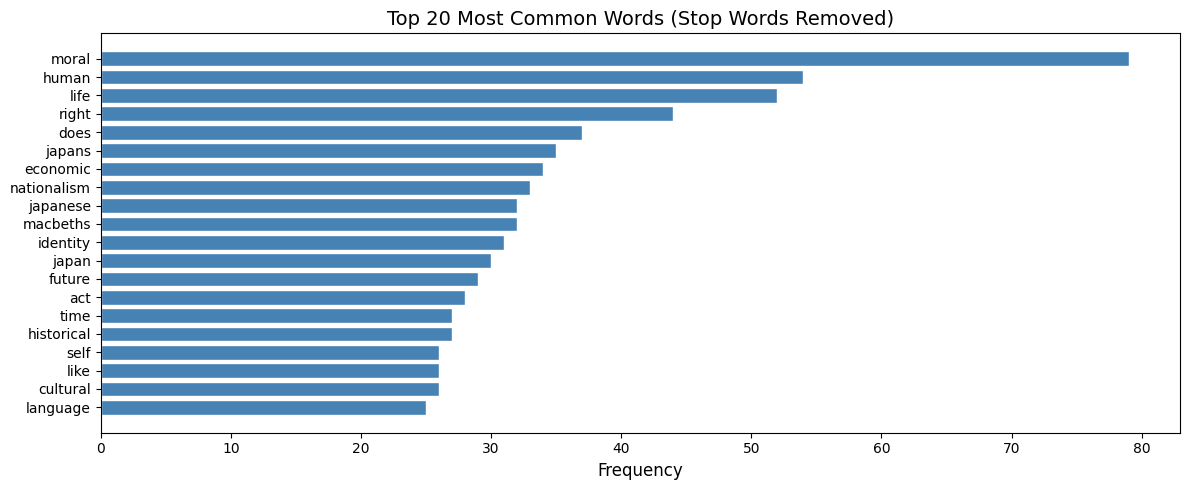

In [25]:
# Pool all words across all documents
all_words = ' '.join(doc_df['document']).split()
word_counts = Counter(all_words)
top20 = word_counts.most_common(20)

print('Top 20 Most Common Words Across All Documents:')
print(f'{"Rank":<6} {"Word":<20} {"Count":<10}')
print('-' * 36)
for rank, (word, count) in enumerate(top20, 1):
    print(f'{rank:<6} {word:<20} {count:<10}')

# Bar chart
words, counts = zip(*top20)
plt.figure(figsize=(12, 5))
bars = plt.barh(list(words)[::-1], list(counts)[::-1], color='steelblue', edgecolor='white')
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 20 Most Common Words (Stop Words Removed)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:**

Look at the words that appear most. Words like *choice*, *self*, *language*, *writing*, or *knowledge* would reflect that most of these essays are from philosophy and reflective essays. Recurring words reveal not just topics but **academic habits** — for example, frequent use of words like *however*, *perhaps*, or *rather* suggests a writing style common in analytical writing.

### <span style="color: #4D516D">6. Bag of Words Count Vectorizer</span>

In [26]:
# Fit CountVectorizer on the documents
cv = CountVectorizer()
bow_matrix = cv.fit_transform(doc_df['document'])

# Convert sparse matrix to a readable DataFrame
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=cv.get_feature_names_out(),
    index=[f'Doc {i}' for i in range(len(doc_df))]
)

print('Bag of Words Matrix (first 5 docs, first 10 words shown):')
print(bow_df.iloc[:5, :10])
print()
print('Each ROW = one document')
print('Each COLUMN = one unique word in the vocabulary')
print('Each VALUE = how many times that word appears in that document')

Bag of Words Matrix (first 5 docs, first 10 words shown):
       abandon  abandoned  abandoning  abate  abduction  abenomics  abes  \
Doc 0        0          0           0      0          0          0     0   
Doc 1        0          0           0      0          0          0     0   
Doc 2        0          0           0      0          0          0     0   
Doc 3        0          0           0      0          0          0     0   
Doc 4        0          0           1      0          0          0     0   

       ability  abjection  able  
Doc 0        0          0     0  
Doc 1        0          0     0  
Doc 2        0          0     0  
Doc 3        0          0     0  
Doc 4        1          0     0  

Each ROW = one document
Each COLUMN = one unique word in the vocabulary
Each VALUE = how many times that word appears in that document


### <span style="color: #4D516D">6. Shape of Bag of Words Matrix</span>

In [27]:
rows, cols = bow_df.shape

print(f'Matrix shape: {rows} rows x {cols} columns')
print(f'  → {rows} documents (chunks of 10 sentences each)')
print(f'  → {cols} unique words in the vocabulary')
print()

# Show sparsity — most cells will be 0
total_cells   = rows * cols
nonzero_cells = (bow_df > 0).sum().sum()
sparsity      = 1 - (nonzero_cells / total_cells)

print(f'Total cells in matrix : {total_cells:,}')
print(f'Non-zero cells        : {nonzero_cells:,}')
print(f'Zero cells            : {total_cells - nonzero_cells:,}')
print(f'Sparsity              : {sparsity:.1%}')
print()
print(f'This means {sparsity:.0%} of the matrix is zeros — most words')
print(f'only appear in a few documents, not all of them.')

Matrix shape: 79 rows x 4622 columns
  → 79 documents (chunks of 10 sentences each)
  → 4622 unique words in the vocabulary

Total cells in matrix : 365,138
Non-zero cells        : 9,273
Zero cells            : 355,865
Sparsity              : 97.5%

This means 97% of the matrix is zeros — most words
only appear in a few documents, not all of them.


### <span style="color: #4D516D">7. Words with Highest Total Counts</span>

In [28]:
# Sum each word's count across all documents
word_totals = bow_df.sum().sort_values(ascending=False)

print('Top 25 Words by Total Count Across All Documents:')
print(f'{"Rank":<6} {"Word":<20} {"Total Count":<12} {"% of all words"}')
print('-' * 55)
grand_total = word_totals.sum()
for rank, (word, count) in enumerate(word_totals.head(25).items(), 1):
    pct = count / grand_total * 100
    print(f'{rank:<6} {word:<20} {int(count):<12} {pct:.2f}%')

print(f'\nTotal word tokens across all documents: {int(grand_total):,}')
print(f'Top 10 words account for: {word_totals.head(10).sum()/grand_total*100:.1f}% of all tokens')

Top 25 Words by Total Count Across All Documents:
Rank   Word                 Total Count  % of all words
-------------------------------------------------------
1      moral                79           0.70%
2      human                54           0.48%
3      life                 52           0.46%
4      right                44           0.39%
5      does                 37           0.33%
6      japans               35           0.31%
7      economic             34           0.30%
8      nationalism          33           0.29%
9      japanese             32           0.28%
10     macbeths             32           0.28%
11     identity             31           0.27%
12     japan                30           0.26%
13     future               29           0.26%
14     act                  28           0.25%
15     historical           27           0.24%
16     time                 27           0.24%
17     cultural             26           0.23%
18     self                 26         

### <span style="color: #4D516D">8. Bag of Words Visualization</span>

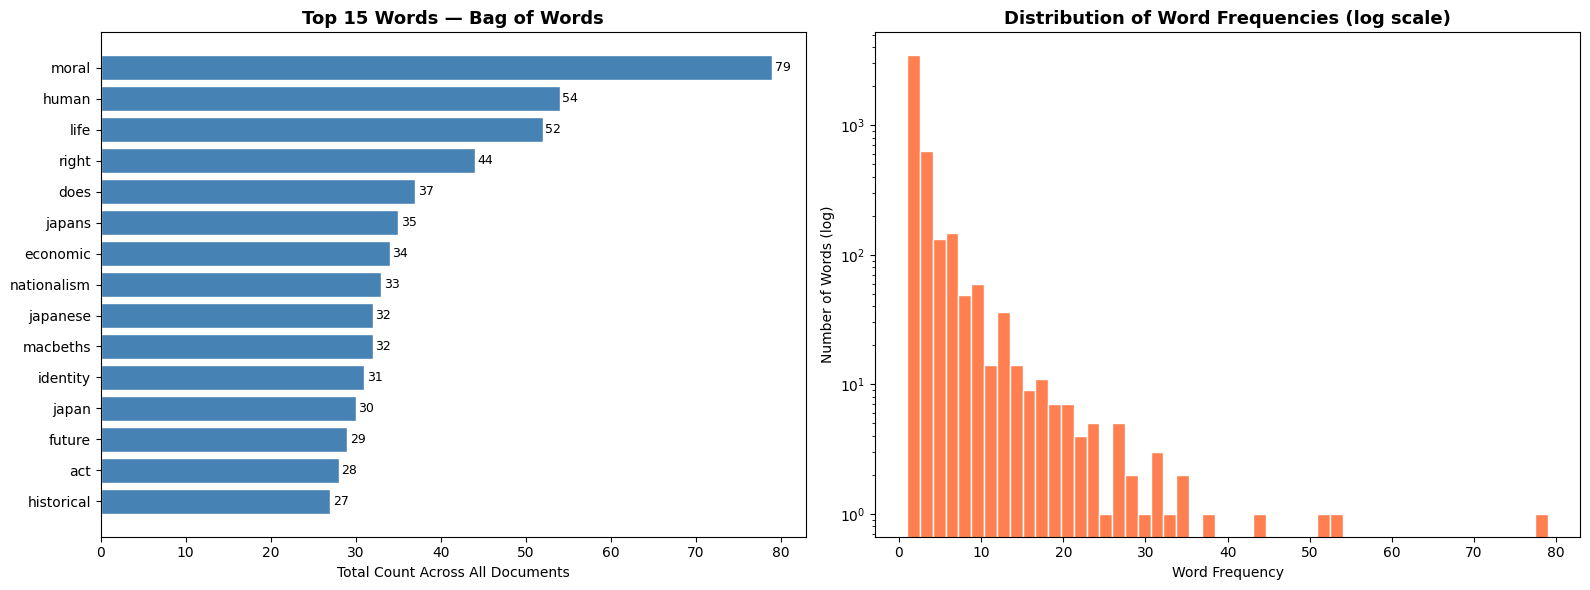

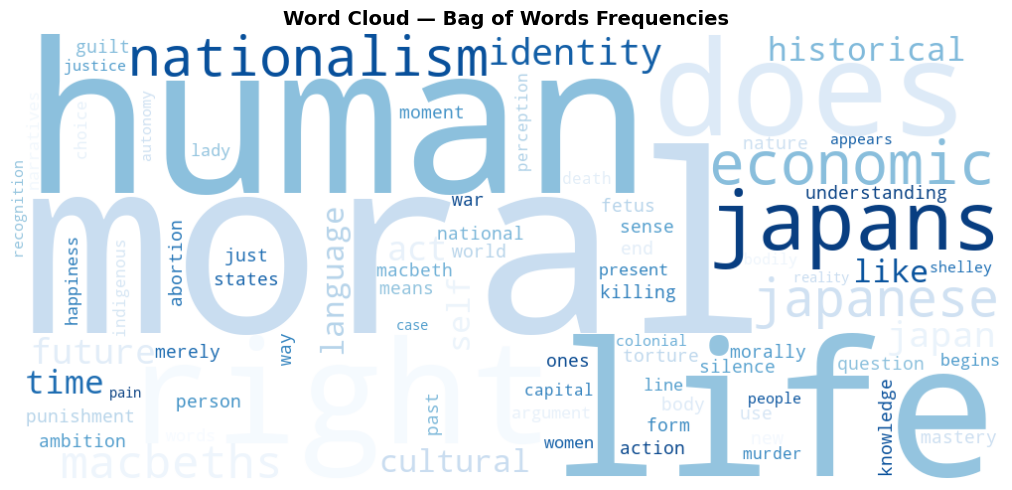

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart: top 15 words ---
top15 = word_totals.head(15)
axes[0].barh(top15.index[::-1], top15.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Words — Bag of Words', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Count Across All Documents')
for i, (word, val) in enumerate(zip(top15.index[::-1], top15.values[::-1])):
    axes[0].text(val + 0.3, i, str(int(val)), va='center', fontsize=9)

# --- Histogram: distribution of word frequencies ---
axes[1].hist(word_totals.values, bins=50, color='coral', edgecolor='white', log=True)
axes[1].set_title('Distribution of Word Frequencies (log scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Frequency')
axes[1].set_ylabel('Number of Words (log)')

plt.tight_layout()
plt.show()

# --- Word cloud ---
freq_dict = dict(zip(word_totals.index, word_totals.values))
wc = WordCloud(width=1000, height=450, background_color='white',
               colormap='Blues', max_words=80).generate_from_frequencies(freq_dict)

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Bag of Words Frequencies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### <span style="color: #4D516D">9. TF-IDF Vectorization</span>

In [30]:
# Fit TF-IDF on the same documents
tfidf_vec    = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(doc_df['document'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vec.get_feature_names_out(),
    index=[f'Doc {i}' for i in range(len(doc_df))]
)

print('TF-IDF Matrix (first 5 docs, first 10 words):')
print(tfidf_df.iloc[:5, :10].round(4))
print()
print('Values are decimal scores (0 to 1), NOT raw counts.')
print('Higher score = more important/distinctive to that specific document.')

TF-IDF Matrix (first 5 docs, first 10 words):
       abandon  abandoned  abandoning  abate  abduction  abenomics  abes  \
Doc 0      0.0        0.0      0.0000    0.0        0.0        0.0   0.0   
Doc 1      0.0        0.0      0.0000    0.0        0.0        0.0   0.0   
Doc 2      0.0        0.0      0.0000    0.0        0.0        0.0   0.0   
Doc 3      0.0        0.0      0.0000    0.0        0.0        0.0   0.0   
Doc 4      0.0        0.0      0.1064    0.0        0.0        0.0   0.0   

       ability  abjection  able  
Doc 0    0.000        0.0   0.0  
Doc 1    0.000        0.0   0.0  
Doc 2    0.000        0.0   0.0  
Doc 3    0.000        0.0   0.0  
Doc 4    0.075        0.0   0.0  

Values are decimal scores (0 to 1), NOT raw counts.
Higher score = more important/distinctive to that specific document.


**How is TF-IDF different from Bag of Words?**

| | Bag of Words | TF-IDF |
|---|---|---|
| **What it measures** | Raw count of each word | Weighted importance of each word |
| **Common words** | Score high (e.g. "choice" = 15) | Penalized if they appear in many docs |
| **Rare/unique words** | Score low | Score high if distinctive to one doc |
| **Output values** | Integers (counts) | Decimals between 0 and 1 |

**TF** (Term Frequency) = how often a word appears in *this* document  
**IDF** (Inverse Document Frequency) = a penalty for words that appear in *many* documents  
**TF-IDF** = TF × IDF → rewards words that are frequent in one doc but rare across others, revealing what makes each section distinctive.

### <span style="color: #4D516D">10. Words with Highest Average TF-IDF Scores</span>

In [31]:
avg_tfidf = tfidf_df.mean().sort_values(ascending=False)

print('Top 25 Words by Average TF-IDF Score:')
print(f'{"Rank":<6} {"Word":<22} {"Avg TF-IDF Score"}')
print('-' * 45)
for rank, (word, score) in enumerate(avg_tfidf.head(25).items(), 1):
    print(f'{rank:<6} {word:<22} {score:.5f}')

# Also show which document each top word is most concentrated in
print('\nTop 10 words and which document they peak in:')
for word in avg_tfidf.head(10).index:
    peak_doc = tfidf_df[word].idxmax()
    peak_val = tfidf_df[word].max()
    print(f'  {word:<20} peaks in {peak_doc} (score: {peak_val:.4f})')

Top 25 Words by Average TF-IDF Score:
Rank   Word                   Avg TF-IDF Score
---------------------------------------------
1      moral                  0.03424
2      human                  0.02392
3      life                   0.02324
4      right                  0.02243
5      macbeths               0.02168
6      does                   0.02060
7      japans                 0.02021
8      language               0.02009
9      economic               0.01855
10     understanding          0.01835
11     nationalism            0.01832
12     japan                  0.01725
13     mastery                0.01704
14     silence                0.01698
15     self                   0.01662
16     punishment             0.01632
17     identity               0.01625
18     japanese               0.01599
19     future                 0.01591
20     time                   0.01557
21     fetus                  0.01540
22     torture                0.01539
23     act                    0.0

### <span style="color: #4D516D">11. Compare Bag of Words and TF-IDF</span>

In [32]:
# Build a comparison table
comparison = pd.DataFrame({
    'bow_total_count' : word_totals,
    'bow_rank'        : range(1, len(word_totals) + 1),
    'tfidf_avg_score' : avg_tfidf,
}).dropna().sort_values('bow_total_count', ascending=False)

comparison['tfidf_rank'] = comparison['tfidf_avg_score'].rank(ascending=False).astype(int)
comparison['rank_diff']  = comparison['bow_rank'] - comparison['tfidf_rank']

print('=== Top 20 by Raw Count — do they rank as high in TF-IDF? ===')
print(f'{"Word":<20} {"BoW Count":<12} {"BoW Rank":<10} {"TF-IDF Rank":<14} {"Rank Diff (BoW - TFIDF)"}')
print('-' * 72)
for word, row in comparison.head(20).iterrows():
    diff_str = f'+{int(row["rank_diff"])}' if row['rank_diff'] > 0 else str(int(row['rank_diff']))
    print(f'{word:<20} {int(row["bow_total_count"]):<12} {int(row["bow_rank"]):<10} {int(row["tfidf_rank"]):<14} {diff_str}')

print()
print('Positive rank diff = word ranks HIGHER in raw count than TF-IDF')
print('  → common everywhere, not distinctive to any one document')
print('Negative rank diff = word ranks HIGHER in TF-IDF than raw count')
print('  → distinctively concentrated in specific documents')

=== Top 20 by Raw Count — do they rank as high in TF-IDF? ===
Word                 BoW Count    BoW Rank   TF-IDF Rank    Rank Diff (BoW - TFIDF)
------------------------------------------------------------------------
moral                79           2678       1              +2677
human                54           1988       2              +1986
life                 52           2441       3              +2438
right                44           3606       4              +3602
does                 37           1211       6              +1205
japans               35           2296       7              +2289
economic             34           1272       9              +1263
nationalism          33           2738       11             +2727
japanese             32           2295       18             +2277
macbeths             32           2518       5              +2513
identity             31           2008       17             +1991
japan                30           2294       12        

### <span style="color: #4D516D">12. Two Visualizations from TF-IDF</span>

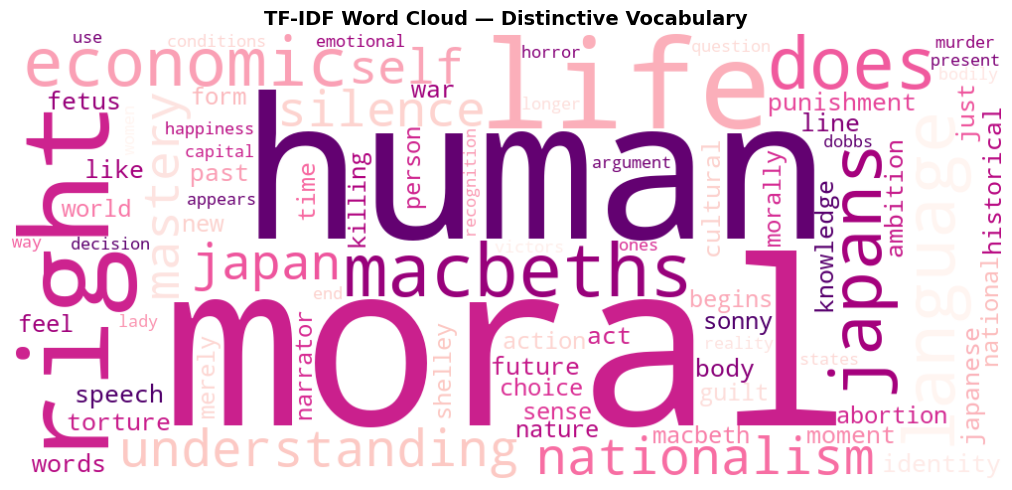

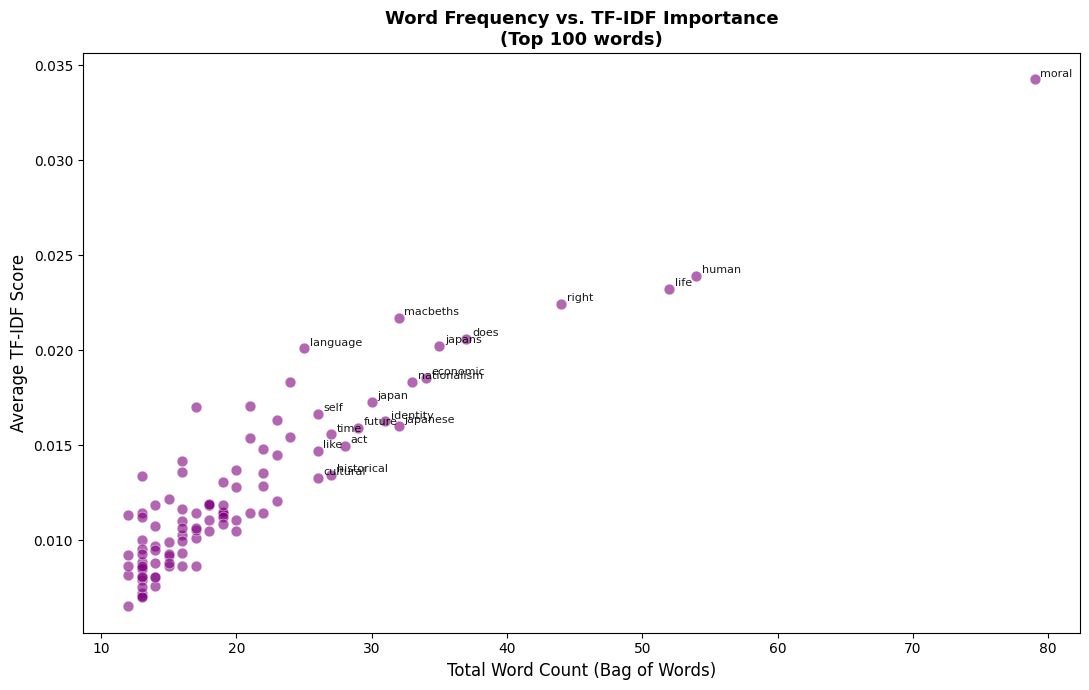

Words in the top-right corner: frequent AND distinctive
Words with high BoW but low TF-IDF: common everywhere, less distinctive
Words with low BoW but high TF-IDF: rare overall but concentrated in specific essays


In [33]:
# --- TF-IDF Word Cloud ---
tfidf_freq_dict = dict(zip(avg_tfidf.index, avg_tfidf.values))

wc_tfidf = WordCloud(width=1000, height=450, background_color='white',
                     colormap='RdPu', max_words=80).generate_from_frequencies(tfidf_freq_dict)

plt.figure(figsize=(14, 5))
plt.imshow(wc_tfidf, interpolation='bilinear')
plt.axis('off')
plt.title('TF-IDF Word Cloud — Distinctive Vocabulary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Scatter: BoW frequency vs TF-IDF importance ---
top100 = comparison.head(100).copy()

plt.figure(figsize=(11, 7))
plt.scatter(top100['bow_total_count'], top100['tfidf_avg_score'],
            alpha=0.6, color='purple', s=60, edgecolors='white', linewidths=0.5)

# Label the top 20 most interesting words
for word, row in top100.head(20).iterrows():
    plt.annotate(word,
                 xy=(row['bow_total_count'], row['tfidf_avg_score']),
                 xytext=(4, 2), textcoords='offset points',
                 fontsize=8, alpha=0.9)

plt.xlabel('Total Word Count (Bag of Words)', fontsize=12)
plt.ylabel('Average TF-IDF Score', fontsize=12)
plt.title('Word Frequency vs. TF-IDF Importance\n(Top 100 words)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Words in the top-right corner: frequent AND distinctive')
print('Words with high BoW but low TF-IDF: common everywhere, less distinctive')
print('Words with low BoW but high TF-IDF: rare overall but concentrated in specific essays')

### <span style="color: #4D516D">13. Reflection</span>

In [34]:
# Summary statistics to support your reflection
print('=== WRITING ANALYSIS SUMMARY ===')
print(f'Total sentences analyzed     : {len(df)}')
print(f'Total documents (chunks)     : {len(doc_df)}')
print(f'Unique vocabulary size       : {len(word_totals)}')
print(f'Total word tokens            : {int(word_totals.sum()):,}')
print(f'Avg sentence length (tokens) : {df["token_count"].mean():.1f} words')
print()

print('Top 10 words by raw count (your most-used vocabulary):')
for i, (word, count) in enumerate(word_totals.head(10).items(), 1):
    print(f'  {i}. {word} ({int(count)}x)')

print()
print('Top 10 words by TF-IDF (your most distinctive vocabulary):')
for i, (word, score) in enumerate(avg_tfidf.head(10).items(), 1):
    print(f'  {i}. {word} ({score:.4f})')

print()
print('Words that are common overall but NOT distinctive (high BoW, lower TF-IDF):')
generic_words = comparison[comparison['rank_diff'] > 10].head(10)
for word, row in generic_words.iterrows():
    print(f'  {word} — BoW rank {int(row["bow_rank"])}, TF-IDF rank {int(row["tfidf_rank"])}')

=== WRITING ANALYSIS SUMMARY ===
Total sentences analyzed     : 785
Total documents (chunks)     : 79
Unique vocabulary size       : 4622
Total word tokens            : 11,324
Avg sentence length (tokens) : 27.5 words

Top 10 words by raw count (your most-used vocabulary):
  1. moral (79x)
  2. human (54x)
  3. life (52x)
  4. right (44x)
  5. does (37x)
  6. japans (35x)
  7. economic (34x)
  8. nationalism (33x)
  9. japanese (32x)
  10. macbeths (32x)

Top 10 words by TF-IDF (your most distinctive vocabulary):
  1. moral (0.0342)
  2. human (0.0239)
  3. life (0.0232)
  4. right (0.0224)
  5. macbeths (0.0217)
  6. does (0.0206)
  7. japans (0.0202)
  8. language (0.0201)
  9. economic (0.0185)
  10. understanding (0.0183)

Words that are common overall but NOT distinctive (high BoW, lower TF-IDF):
  moral — BoW rank 2678, TF-IDF rank 1
  human — BoW rank 1988, TF-IDF rank 2
  life — BoW rank 2441, TF-IDF rank 3
  right — BoW rank 3606, TF-IDF rank 4
  does — BoW rank 1211, TF-IDF r